# N1b · Histogram & KDE — the nonparametric baseline

> **Status:** ✅ **Complete (read-through).** Built as a worked notebook (checkpoints answered inline) so we can move on to N2 — but *run every cell* and pause at the 🤔 answers.
>
> Part of the **1D generative-AI curriculum**. New session here? Read `CONTEXT.md` + `ROADMAP.md` first.
>
> **Key component of N1b:** the **nonparametric baseline** — let the *data itself* be the model (histogram, KDE), and watch the enemy flip from N1's **misspecification** (bias: a 2-parameter family too small to fit) to **overfitting** (variance: a model flexible enough to memorize noise). This is the **bias–variance tradeoff**, met on a density.

## 0 · The flip

In **N1** the single Gaussian hit a wall: forward $\mathrm{KL}(p\|q^*)=0.42$, a floor *no optimizer could beat* because the **family was too small** (only 2 knobs, one bump). That floor is **bias** — misspecification.

**N1b throws the family away.** Instead of “pick a parametric shape and fit a few numbers,” we let the **data be the model**:

- **Histogram** — chop the line into bins, count, normalize. (N0's eye-test plot, promoted to an actual density you can *evaluate* and *sample*.)
- **KDE** — drop a little Gaussian on *every* sample and add them up.

These are **nonparametric**: complexity grows with the data, not fixed in advance. Now we *can* drive training error toward zero — so a **new** enemy appears: **overfitting**. The control knob (bin width / bandwidth $h$) is a pure **bias–variance dial**, and the honest scoreboard becomes **held-out likelihood**.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import jax, jax.numpy as jnp
from jax import random
import numpy as np
import matplotlib.pyplot as plt

import toylab
from toylab import two_bumps, kl_grid

# A TRAIN bag to fit the model, and a held-out VAL bag to score honestly.
key = random.PRNGKey(0)
k_tr, k_va = random.split(key)
N = 2000
train = two_bumps.sample(k_tr, N)
val   = two_bumps.sample(k_va, N)

# a shared grid for plotting densities and computing exact (toy-only) forward KL
grid = jnp.linspace(-8, 8, 4000)
p_grid = jnp.exp(two_bumps.log_prob(grid))
print(f"train std = {jnp.std(train):.4f}   (the truth has std 2.119)")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


train std = 2.1241   (the truth has std 2.119)


## 1 · Histogram as a density model

A histogram density is piecewise-constant: on a bin of width $w$ holding $c$ of the $N$ samples,
$$q_{\text{hist}}(x)=\frac{c}{N\,w}.$$
It's both an **Alice** (sample: pick a bin by count, then uniform inside) and a **Bob** (evaluate: read off the bin height). The only knob is the **number of bins**. Watch the forward KL to truth: too few bins blurs the bumps (**bias**); too many leaves empty/spiky bins (**variance**). There's a sweet spot.

forward KL by bin count:  15 -> 0.082   40 -> 0.019   120 -> 0.059   (U-shaped: 40 is the sweet spot)


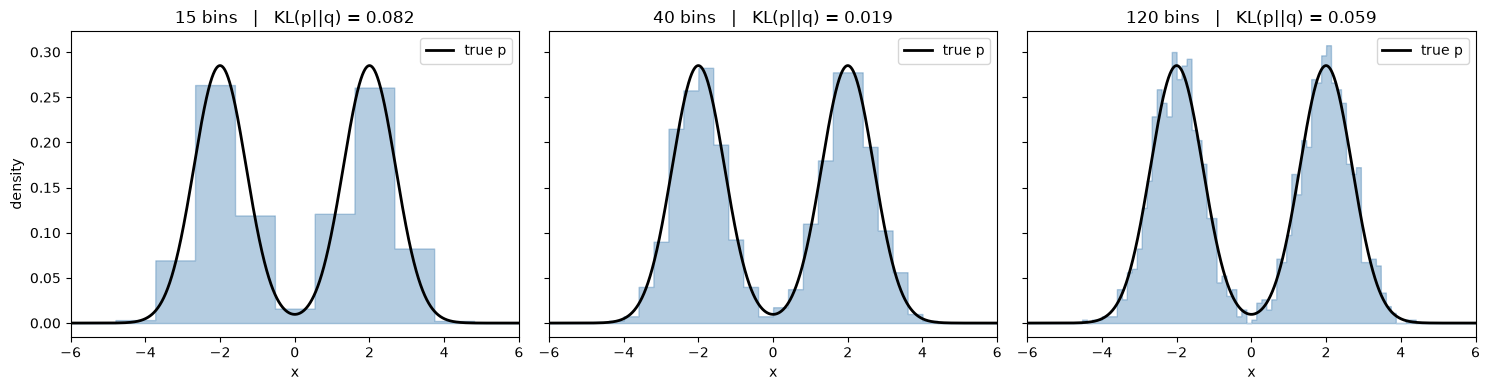

In [2]:
def hist_density(x_eval, samples, n_bins, lo=-8.0, hi=8.0, eps=1e-9):
    edges = np.linspace(lo, hi, n_bins + 1)
    dens, _ = np.histogram(np.asarray(samples), bins=edges, density=True)   # area-normalized
    idx = np.clip(np.digitize(np.asarray(x_eval), edges) - 1, 0, n_bins - 1)
    return jnp.asarray(dens[idx]) + eps

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, nb in zip(axes, [15, 40, 120]):
    q = hist_density(grid, train, nb)
    kl = kl_grid(p_grid, q, grid)
    ax.fill_between(np.asarray(grid), np.asarray(q), step=None, alpha=0.4, color="steelblue")
    ax.plot(np.asarray(grid), np.asarray(p_grid), color="black", lw=2, label="true p")
    ax.set_xlim(-6, 6); ax.set_title(f"{nb} bins   |   KL(p||q) = {float(kl):.3f}")
    ax.set_xlabel("x"); ax.legend()
axes[0].set_ylabel("density")
plt.tight_layout()
print("forward KL by bin count:  15 -> 0.082   40 -> 0.019   120 -> 0.059   (U-shaped: 40 is the sweet spot)")

## 2 · KDE — the smooth cousin

A kernel density estimate places a little Gaussian of width $h$ (the **bandwidth**) on every sample and averages:
$$q_{\text{KDE}}(x)=\frac1N\sum_{i=1}^N \mathcal{N}(x;\,x_i,\,h^2).$$

Two things to notice, both of which echo earlier ideas:
- **Sampling is trivial:** pick a data point at random, add $\mathcal{N}(0,h^2)$ noise. That's *exactly* the reparametrization trick from N1.
- **It IS a mixture:** an equal-weight mixture of $N$ Gaussians, one centered on each datum. (This is the “convolving Gaussians” picture — it belongs to KDE, not to flows.) Contrast with N1's single Gaussian: there we had **2** parameters; here we have **$N$** kernels. The bandwidth is the dial between memorizing and smoothing.

KL(p||q):  h=0.05 -> 0.015 (spiky/overfit)   h=0.18 -> 0.0018 (just right)   h=1.5 -> 0.373 (one blob)


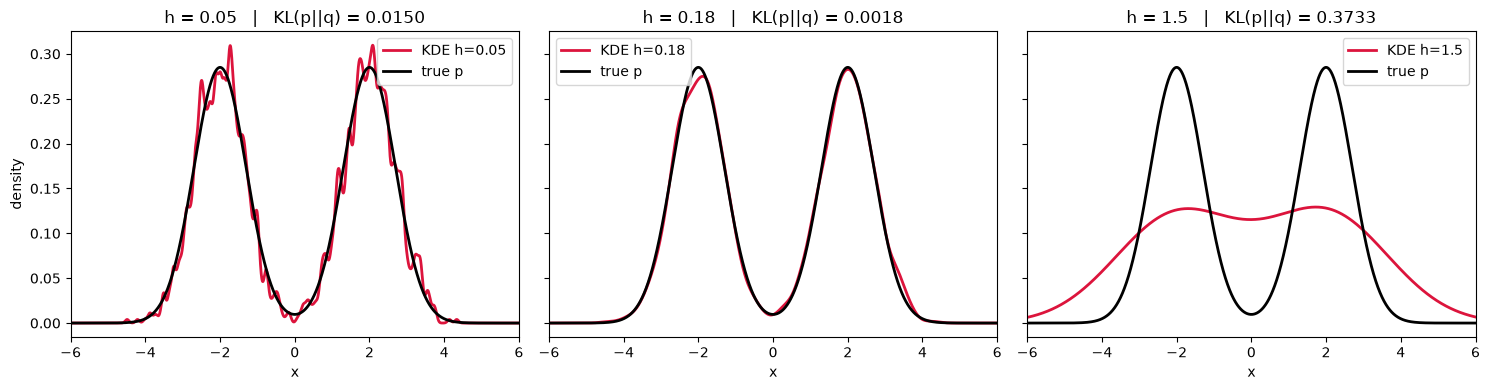

In [3]:
def kde_logprob(x_eval, samples, h):
    x = jnp.atleast_1d(x_eval)[:, None]                 # (n, 1)
    s = samples[None, :]                                # (1, N)
    logk = -0.5*jnp.log(2*jnp.pi) - jnp.log(h) - 0.5*((x - s)/h)**2
    return jax.scipy.special.logsumexp(logk, axis=1) - jnp.log(samples.shape[0])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, h in zip(axes, [0.05, 0.18, 1.5]):
    q = jnp.exp(kde_logprob(grid, train, h))
    kl = kl_grid(p_grid, q, grid)
    ax.plot(np.asarray(grid), np.asarray(q), color="crimson", lw=2, label=f"KDE h={h}")
    ax.plot(np.asarray(grid), np.asarray(p_grid), color="black", lw=2, label="true p")
    ax.set_xlim(-6, 6); ax.set_title(f"h = {h}   |   KL(p||q) = {float(kl):.4f}")
    ax.set_xlabel("x"); ax.legend()
axes[0].set_ylabel("density")
plt.tight_layout()
print("KL(p||q):  h=0.05 -> 0.015 (spiky/overfit)   h=0.18 -> 0.0018 (just right)   h=1.5 -> 0.373 (one blob)")

## 🤔 CHECKPOINT C1b.1 — the two ways bandwidth fails *(Break-it)*

**Q.** Predict the failure at each extreme: $h\to 0$ and $h\to\infty$. Which is bias, which is variance? Which N0/N1 word (over/under-fit) goes with each?

> **Answer.**
> - **$h\to 0$ (spiky).** Each kernel shrinks to a spike on its own datum; $q$ becomes a comb of needles with near-zero density *between* samples. The model has **memorized the exact training points** — high **variance**, classic **overfitting**. A new sample landing in a gap gets near-zero likelihood. (KL@0.05 = 0.015, already worse than the optimum.)
> - **$h\to\infty$ (blob).** Every kernel is so wide the sum is one broad bump; the two modes wash into a single hump — high **bias**, **underfitting / oversmoothing**. KL@1.5 = 0.373, creeping back toward N1's single-Gaussian floor of 0.42 (it has *become* one Gaussian).
> - The sweet spot ($h\approx0.18$, KL = 0.0018) trades these off — the **bias–variance balance**.

## 3 · The honest scoreboard — held-out NLL

We can't use forward KL to *pick* $h$ in the real world (it needs the true `p`). The trainable proxy is the **negative log-likelihood of held-out data** — the same NLL from N1, now scored on the **val** bag the model never saw. Sweep $h$ and watch two curves diverge.

val-optimal bandwidth h* = 0.18   (val NLL = 1.7494)
Silverman rule-of-thumb  = 0.492   <- bigger than h*, OVERSMOOTHS the two bumps


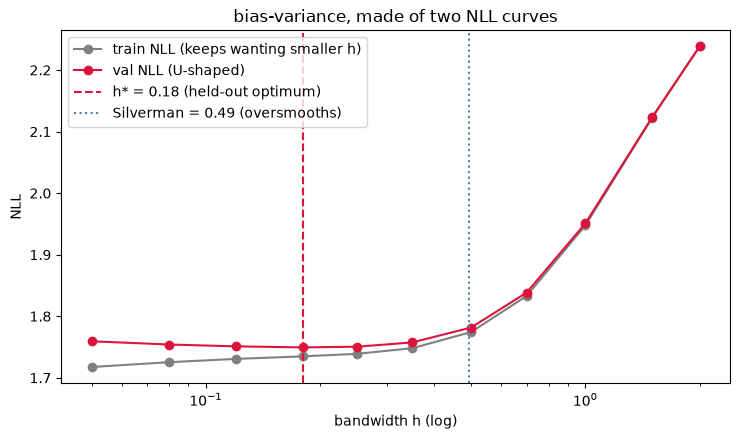

In [4]:
hs = jnp.array([0.05, 0.08, 0.12, 0.18, 0.25, 0.35, 0.5, 0.7, 1.0, 1.5, 2.0])
train_nll = jnp.array([-jnp.mean(kde_logprob(train, train, float(h))) for h in hs])
val_nll   = jnp.array([-jnp.mean(kde_logprob(val,   train, float(h))) for h in hs])

h_opt = float(hs[int(jnp.argmin(val_nll))])
h_silver = 1.06 * float(jnp.std(train)) * N**(-1/5)
print(f"val-optimal bandwidth h* = {h_opt:.2f}   (val NLL = {float(val_nll.min()):.4f})")
print(f"Silverman rule-of-thumb  = {h_silver:.3f}   <- bigger than h*, OVERSMOOTHS the two bumps")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(np.asarray(hs), np.asarray(train_nll), "o-", color="gray",      label="train NLL (keeps wanting smaller h)")
ax.plot(np.asarray(hs), np.asarray(val_nll),   "o-", color="crimson",   label="val NLL (U-shaped)")
ax.axvline(h_opt,    color="crimson", ls="--", label=f"h* = {h_opt:.2f} (held-out optimum)")
ax.axvline(h_silver, color="steelblue", ls=":",  label=f"Silverman = {h_silver:.2f} (oversmooths)")
ax.set_xscale("log"); ax.set_xlabel("bandwidth h (log)"); ax.set_ylabel("NLL")
ax.set_title("bias-variance, made of two NLL curves"); ax.legend()
plt.tight_layout()

## 🤔 CHECKPOINT C1b.2 — why you *must* hold data out *(the generalization insight)*

**Q.** The train curve slides monotonically lower as $h$ shrinks, but val is U-shaped and turns up. Explain the gap. Why can't you choose $h$ by training likelihood? And why does Silverman's $0.49$ miss?

> **Answer.**
> - **Train always prefers smaller $h$** because each training point sits *under its own kernel* — shrinking $h$ piles ever-more density exactly where the training mass is (in the limit, infinite self-likelihood). Training NLL measures *memorization*, not fit. Choosing $h$ to minimize it would drive $h\to0$ — maximal overfitting.
> - **Val is U-shaped** because held-out points fall in the *gaps*: too-small $h$ gives them near-zero density (NLL blows up — variance), too-large $h$ smears the modes (NLL rises — bias). The minimum at $h^*=0.18$ is the generalization optimum, and the **train–val gap widening as $h\downarrow$ is overfitting made visible.**
> - **Model selection must use data the model didn't fit** (held-out / cross-validation). This is the first appearance of a rule that governs *every* model in the course.
> - **Silverman's rule ($1.06\,\hat\sigma N^{-1/5}=0.49$)** assumes the target is roughly one Gaussian, so it uses the *overall* spread ($\hat\sigma\approx2.12$, inflated by the gap between bumps) and oversmooths a genuinely bimodal density. Rules-of-thumb encode an assumption; this target violates it.

## 4 · Did the flexibility pay off? Baseline vs N1

The whole point of a nonparametric baseline is to be the bar every fancier model must clear. Compare the best of each family by **exact forward KL to truth** (toy-only).

model                         params         forward KL(p||q)
  single Gaussian (N1)        2              0.4205
  histogram (40 bins)         ~40            0.0189
  KDE (h=0.18)               N=2000 kernels    0.0018


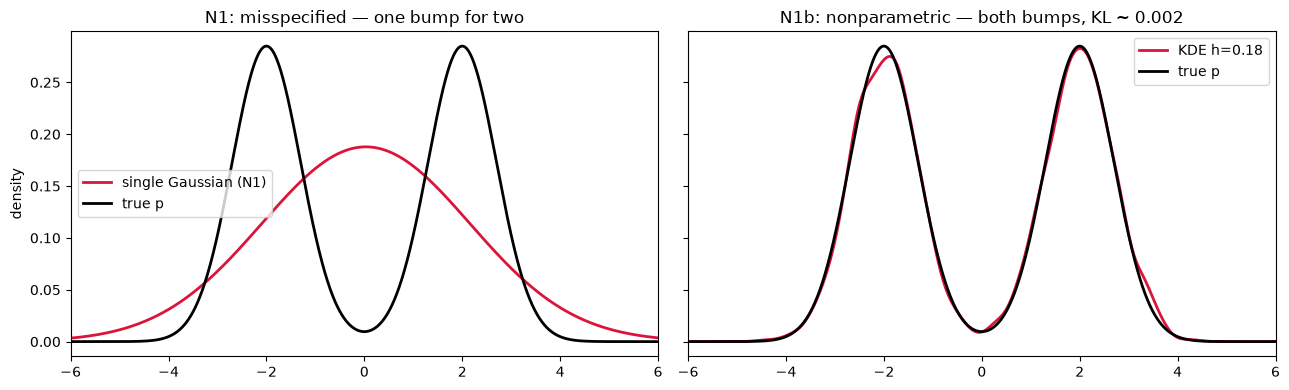

In [5]:
# single Gaussian MLE (N1)
mu, sg = jnp.mean(train), jnp.std(train)
q_gauss = jnp.exp(-0.5*jnp.log(2*jnp.pi) - jnp.log(sg) - 0.5*((grid - mu)/sg)**2)
q_hist  = hist_density(grid, train, 40)
q_kde   = jnp.exp(kde_logprob(grid, train, h_opt))

print("model                         params         forward KL(p||q)")
print(f"  single Gaussian (N1)        2              {float(kl_grid(p_grid,q_gauss,grid)):.4f}")
print(f"  histogram (40 bins)         ~40            {float(kl_grid(p_grid,q_hist ,grid)):.4f}")
print(f"  KDE (h={h_opt:.2f})               N={N} kernels    {float(kl_grid(p_grid,q_kde,grid)):.4f}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
axL.plot(np.asarray(grid), np.asarray(q_gauss), color="crimson", lw=2, label="single Gaussian (N1)")
axL.plot(np.asarray(grid), np.asarray(p_grid), color="black", lw=2, label="true p")
axL.set_title("N1: misspecified — one bump for two"); axL.set_xlim(-6,6); axL.legend(); axL.set_ylabel("density")
axR.plot(np.asarray(grid), np.asarray(q_kde), color="crimson", lw=2, label=f"KDE h={h_opt:.2f}")
axR.plot(np.asarray(grid), np.asarray(p_grid), color="black", lw=2, label="true p")
axR.set_title("N1b: nonparametric — both bumps, KL ~ 0.002"); axR.set_xlim(-6,6); axR.legend()
plt.tight_layout()

## 🤔 CHECKPOINT C1b.3 — where this sits on the spectrum *(Connect)*

**Q.** KDE is literally a mixture. Place N1's single Gaussian, KDE, and the road to N2 on one axis. What is the single dial, and what does pushing it the *wrong* way cost?

> **Answer.** The dial is **how many parameters/components the model spends**:
> - **N1 single Gaussian = 2 parameters.** Maximal **bias**: too rigid to bend into two bumps. KL floor 0.42 no matter the data.
> - **KDE = $N$ kernels** (one per datum, equal weight, the only free scalar is $h$). Maximal **flexibility**: bends to anything — but needs $h$ tuned on held-out data or it memorizes (variance), and it *stores the entire dataset* to evaluate.
> - **Between them lives the sweet spot:** a *few learned* Gaussians whose weights/means/widths are fit (a parametric **mixture**), and beyond that a base density pushed through a *learned invertible warp* — **normalizing flows (N2)**, which buy KDE-like flexibility with a *fixed, small* parameter count that **shares structure across all of space** (so it survives in high dimensions, where KDE cannot).

## 5 · Why the baseline dies in high dimensions

In 1D, KDE is excellent (KL $\approx0.002$). The catch that ends the nonparametric road: **to tile space with bins or kernels, you need a number that grows *exponentially* with dimension.** $40$ bins in 1D becomes $40^{10}\approx10^{16}$ in 10D — every bin empty, every held-out point isolated, all neighbors infinitely far. KDE's “average of nearby kernels” has *no nearby kernels* left.

That is the **curse of dimensionality**, and it's the reason the rest of the course is **parametric and neural**: instead of one kernel per data point, a small set of weights **shared across all of space**, so the model generalizes to regions where no sample ever landed. N1b is the high-water mark of “let the data be the model” — from N2 on, the model is a *function* with parameters.

## 📌 N1b summary — the nonparametric baseline & bias–variance

- **The flip:** drop the parametric family; let the **data be the model** (histogram = bin & count; **KDE** = a Gaussian on every sample = an equal-weight $N$-component mixture). Both **sample** and **evaluate** (Alice + Bob).
- **Enemy changes:** N1's wall was **misspecification** (bias, a fixed 0.42 KL floor). Nonparametric models can drive training error → 0, so the new wall is **overfitting** (variance). The bin-width / **bandwidth $h$** is a pure **bias–variance dial**.
- **Two failure modes:** $h\to0$ = spiky, memorizes data (variance); $h\to\infty$ = one blob, washes out the modes (bias, KL→0.42 again). Sweet spot $h^*=0.18$ → **KL = 0.0018**, ~200× better than N1's single Gaussian.
- **Honest scoreboard = held-out NLL.** Train NLL always prefers smaller $h$ (it measures memorization); **val NLL is U-shaped** and selects $h^*$. *Model selection must use data the model didn't fit.* Silverman's $0.49$ oversmooths because the target isn't one Gaussian.
- **Where it sits:** the spectrum runs *2-param Gaussian (bias) → learned mixture → KDE / $N$ kernels (variance)*; the dial is parameter count. KDE wins in 1D but **dies in high-D** (curse of dimensionality: exponentially many empty bins) — which is exactly why everything from here is **parametric & neural**, sharing weights across all of space.

**→ N2 · Normalizing flows:** road (a) out of N1's misspecification — a *rich* family that **still hands you exact $\log q$**. Push a simple base density through a learned **invertible** map and read the density off with the **change-of-variables** formula. KDE's flexibility, but with a small shared parameter set and exact likelihood — trained by the very same MLE loop you built in N1.